### **Importing Libraries**

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac

# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Sample Data**

In [11]:
# Load sample dataset
data_path = mne.datasets.sample.data_path()
raw_fname = os.path.join(data_path, 'MEG/sample/sample_audvis_filt-0-40_raw.fif')
raw = mne.io.read_raw_fif(raw_fname, preload=True)

# High-pass filter the data
raw.filter(l_freq=0.5, h_freq=40, verbose=False)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>

### **Extracting Events and Creating Epochs**

C:\Users\lacom\AppData\Local\Temp\ipykernel_14252\298206401.py:7: RuntimeWarning: event 5 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);
C:\Users\lacom\AppData\Local\Temp\ipykernel_14252\298206401.py:7: RuntimeWarning: event 32 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);


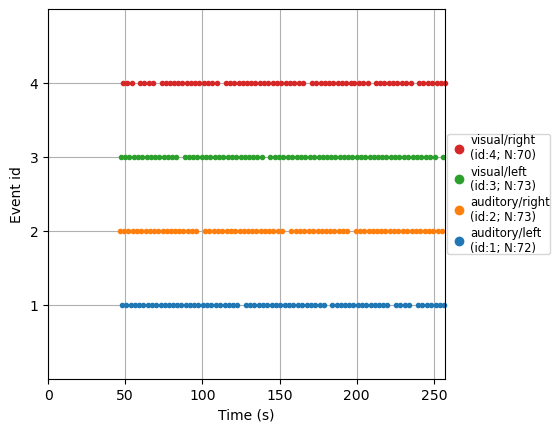

In [12]:
# Extract events 
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)


event_id = {"visual/left": 3, "visual/right": 4,
            "auditory/left": 1, "auditory/right": 2}
fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);

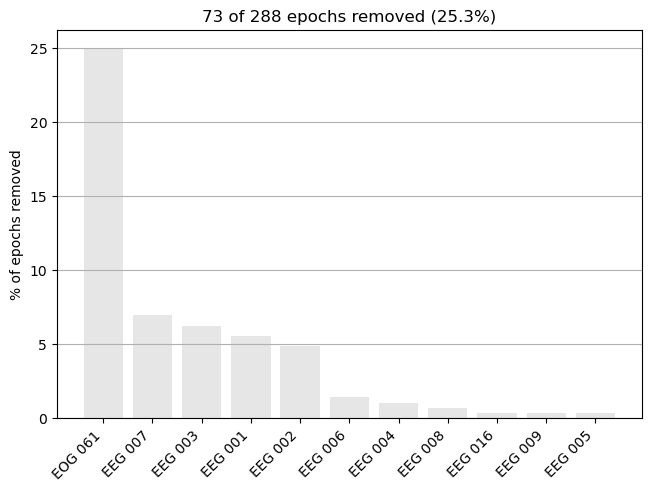

In [13]:

# Epochs parameters
tmin = -0.1  # Start of epoch in seconds
tmax = 0.4   # End of epoch in seconds
baseline = None  # No baseline correction
reject = dict(eeg=80e-6, eog=40e-6)
picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=True, stim=False, exclude='bads')

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, 
                    baseline=baseline, reject=reject, preload=True)


# Separate epochs for each event type
epochs_event1 = epochs['auditory/left']
epochs_event2 = epochs['auditory/right']
epochs_event3 = epochs['visual/left']
epochs_event4 = epochs['visual/right']


epochs.drop_bad()

fig = epochs.plot_drop_log()

### Machine Learning

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from mne.decoding import SlidingEstimator, cross_val_multiscore

In [15]:
#To keep chance level at 50% accuracy, we first equalize the number of epochs in each condition.
epochs.equalize_event_counts(event_id)

# Separate auditory and visual epochs
auditory_epochs = epochs['auditory']
visual_epochs = epochs['visual']

# Print information about the equalized epochs
print(auditory_epochs)
print(visual_epochs)

<Epochs | 98 events (all good), -0.1 – 0.4 s (baseline off), ~6.3 MiB, data loaded,
 'auditory/left': 49
 'auditory/right': 49>
<Epochs | 98 events (all good), -0.1 – 0.4 s (baseline off), ~6.3 MiB, data loaded,
 'visual/left': 49
 'visual/right': 49>


In [16]:
# Step 1: Assume 'epochs' is your EEG data (already created in previous steps)
# Get the data (shape: [n_epochs, n_channels, n_timepoints])
X = epochs.get_data()  # Shape: (n_epochs, n_channels, n_timepoints)

# Step 2: Create feature names (channel-timepoint pairs)
feature_names = []
n_channels = X.shape[1]
n_timepoints = X.shape[2]

for ch in range(n_channels):  # Iterate over channels
    for t in range(n_timepoints):  # Iterate over time points
        feature_names.append(f"Channel_{ch}_Time_{t}")

# Step 3: Flatten the data (preserving channel-timepoint structure)
X_flattened = X.reshape(X.shape[0], -1)  # Shape: (n_epochs, n_channels * n_timepoints)

# Step 4: Initialize the label array
y = np.empty(len(epochs.events), dtype=int)

# Step 5: Assign labels based on event condition (auditory/visual)
# Assuming event_id is already defined as you have in your previous code
idx_auditory_left = epochs.events[:, 2] == event_id['auditory/left']
idx_auditory_right = epochs.events[:, 2] == event_id['auditory/right']
idx_visual_left = epochs.events[:, 2] == event_id['visual/left']
idx_visual_right = epochs.events[:, 2] == event_id['visual/right']

y[idx_auditory_left] = 0  # Auditory event = 0
y[idx_auditory_right] = 0  # Auditory event = 0
y[idx_visual_left] = 1     # Visual event = 1
y[idx_visual_right] = 1    # Visual event = 1

# Step 6: Create a DataFrame with flattened data and feature names
X_df = pd.DataFrame(X_flattened, columns=feature_names)

# Step 7: Add the labels to the DataFrame (optional)
X_df['label'] = y

# Step 8: Now X_df contains your features (with meaningful names) and labels
# You can proceed with training a machine learning model or feature importance analysis

# Check the first few rows of the DataFrame
X_df.head()


,Channel_0_Time_0,Channel_0_Time_1,Channel_0_Time_2,Channel_0_Time_3,Channel_0_Time_4,Channel_0_Time_5,Channel_0_Time_6,Channel_0_Time_7,Channel_0_Time_8,Channel_0_Time_9,...,Channel_59_Time_67,Channel_59_Time_68,Channel_59_Time_69,Channel_59_Time_70,Channel_59_Time_71,Channel_59_Time_72,Channel_59_Time_73,Channel_59_Time_74,Channel_59_Time_75,label
0,1.704028e-06,-0.000002,-8.642815e-07,0.000008,1.068054e-05,0.000002,-5.638665e-06,-0.000002,0.000006,1.078293e-05,...,-0.000002,-4.750142e-06,-0.000001,0.000005,0.000006,0.000002,-8.924439e-07,-8.100733e-07,-3.905184e-07,0
1,7.292041e-06,0.000016,1.457130e-05,0.000005,6.832226e-07,0.000007,1.151345e-05,0.000005,-0.000004,-1.781838e-06,...,-0.000010,-8.892214e-06,-0.000005,-0.000006,-0.000011,-0.000014,-1.054885e-05,-7.359091e-06,-9.906539e-06,1
2,1.811900e-06,-0.000001,2.901475e-06,0.000007,4.892741e-06,0.000003,3.348234e-06,0.000001,-0.000005,-8.654859e-06,...,-0.000003,-9.080384e-07,-0.000002,-0.000002,-0.000001,-0.000003,-4.129826e-06,-2.081382e-06,-1.284170e-06,0
3,6.893292e-06,0.000004,1.485299e-06,-0.000003,-5.411155e-06,-0.000004,-2.224403e-06,-0.000003,-0.000002,8.338463e-07,...,-0.000007,-8.042402e-06,-0.000005,-0.000003,-0.000006,-0.000011,-1.130252e-05,-8.757715e-06,-8.746296e-06,1
4,5.335660e-08,-0.000009,-6.867632e-06,0.000004,8.059054e-06,0.000002,1.648943e-08,0.000004,0.000003,-5.127433e-06,...,-0.000012,-6.220755e-06,-0.000003,-0.000007,-0.000009,-0.000005,-3.758877e-07,-3.690390e-06,-1.127062e-05,0


In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# Assuming 'X_df' is the DataFrame with flattened EEG data and labels
# And that 'y' is the array with the corresponding labels
X = X_df.drop(columns='label')  # Features (drop the label column)
y = X_df['label']  # Labels

# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 2: Define the hyperparameter grid for grid search
param_grid = {
    'n_estimators': [100, 200],  # Number of trees
    'learning_rate': [0.01, 0.1],  # Learning rate
    'max_depth': [3, 5, 7],  # Maximum depth of each tree
    'subsample': [0.8, 1.0],  # Fraction of samples used for each tree
    'colsample_bytree': [0.8, 1.0],  # Fraction of features used for each tree
}

# Step 3: Set up the XGBoost classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Step 4: Set up the k-fold cross-validation (Stratified for balanced class distribution)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 5: Perform GridSearchCV for hyperparameter tuning with k-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Step 6: Output the best parameters found by the grid search
print("Best hyperparameters found: ", grid_search.best_params_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:58:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best hyperparameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [18]:

# Train the final model with the best hyperparameters
best_model = grid_search.best_estimator_

# Fit the model on the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Evaluate the accuracy on the test set
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.4f}")

c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:58:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test set accuracy: 0.9250


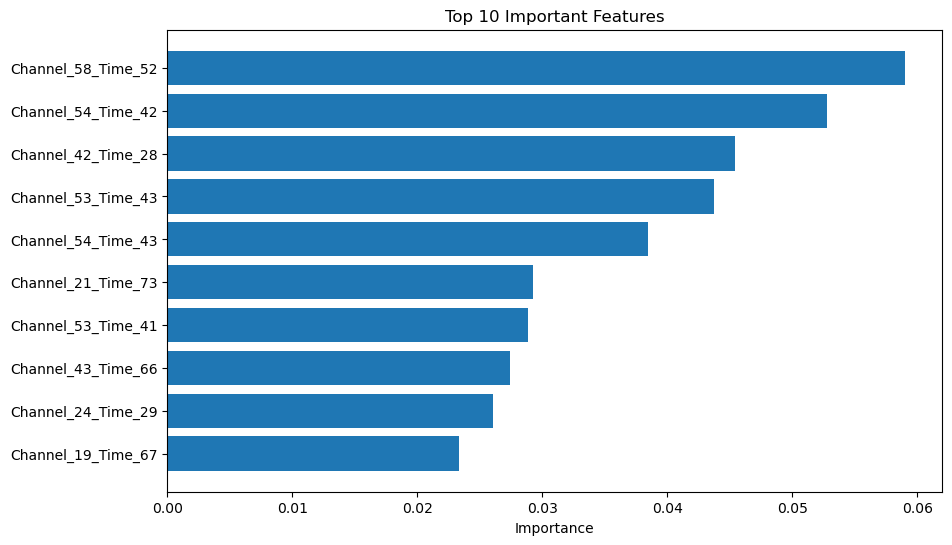

                 feature  importance
4460  Channel_58_Time_52    0.059050
4146  Channel_54_Time_42    0.052766
3220  Channel_42_Time_28    0.045402
4071  Channel_53_Time_43    0.043757
4147  Channel_54_Time_43    0.038485
1669  Channel_21_Time_73    0.029263
4069  Channel_53_Time_41    0.028868
3334  Channel_43_Time_66    0.027445
1853  Channel_24_Time_29    0.026030
1511  Channel_19_Time_67    0.023333


In [19]:
# Get feature importance from the trained model
# Using the model's feature_importances_ attribute
importances = best_model.feature_importances_

# Step 10: Create a DataFrame of feature importances (with channel-timepoint as the feature names)
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

# Step 11: Visualize the top 10 most important features
top_10_features = feature_importances_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features['feature'], top_10_features['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()  # To display the most important feature at the top
plt.show()

# Step 12: Optionally, output the top important features for further analysis
print(top_10_features)
